# Utility Filters

| Function | Description |
| --- | --- |
| `dc_block` | First-order DC blocking filter. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.filters import dc_block, highpass
from python.generators import generate_dc, generate_impulse, generate_sine

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Single-panel analysis of `dc_block`, a first-order IIR high-pass filter optimised for real-time DC removal:

`H(z) = (1 − z⁻¹) / (1 − R z⁻¹)`,  where R ≈ 0.995 sets the −3 dB point to about 20 Hz at 44 100 Hz.

**Three sub-plots:**
- **Left — frequency response (dB):** flat above ≈ 20 Hz; steep −20 dB/oct rolloff below; DC (0 Hz) is fully rejected (H(1) = 0)
- **Centre — step response:** signal starts at 1.0 on a unit step input and decays slowly toward 0 — the integrating action of the pole at z = R; in steady state any DC offset is cancelled
- **Right — audio passthrough:** a 500 Hz sine with a DC bias before (dashed) and after (solid) filtering; the bias is removed while the tone is preserved unchanged above 20 Hz

`dc_block` is the standard pre-processing step before any audio algorithm sensitive to DC offset (e.g., hard clippers, compressors, pitch detectors). Its one-multiply-per-sample cost makes it suitable for every channel in a VCV Rack patch.


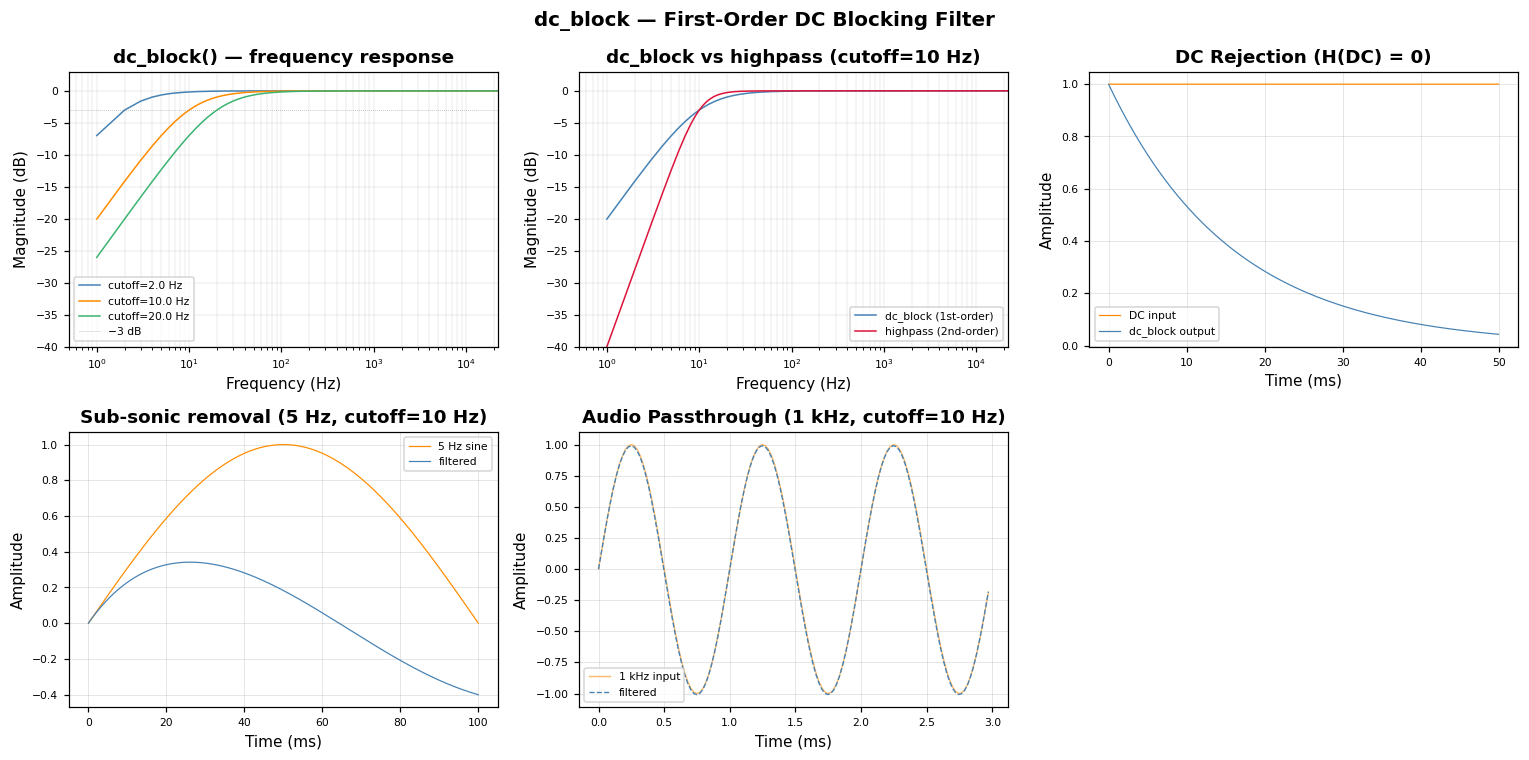

In [2]:
FS = 44100
DURATION = 1.0

_, impulse = generate_impulse(fs=FS, duration=DURATION)
_, dc_sig = generate_dc(amplitude=1.0, fs=FS, duration=DURATION)
_, sine_low = generate_sine(freq=5.0, fs=FS, duration=DURATION)
_, sine_audio = generate_sine(freq=1000.0, fs=FS, duration=DURATION)

CUTOFFS = [2.0, 10.0, 20.0]
COLORS = ["steelblue", "darkorange", "mediumseagreen"]

freqs = np.fft.rfftfreq(len(impulse), d=1.0 / FS)


def _db(h: np.ndarray) -> np.ndarray:
    return 20 * np.log10(np.abs(np.fft.rfft(h)) + 1e-12)


fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Frequency response vs cutoff
ax = axes[0, 0]
for cutoff, color in zip(CUTOFFS, COLORS):
    h = dc_block(impulse, cutoff=cutoff, fs=FS)
    mask = freqs > 0
    ax.semilogx(freqs[mask], _db(h)[mask], color=color, linewidth=1.0, label=f"cutoff={cutoff} Hz")
ax.set_title("dc_block() — frequency response", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(0.5, FS / 2)
ax.set_ylim(-40, 3)
ax.axhline(-3, color="gray", linewidth=0.5, linestyle=":", alpha=0.7, label="−3 dB")
ax.legend(fontsize=7)
ax.grid(True, which="both", linewidth=0.3, alpha=0.5)

# Comparison with biquad highpass
ax = axes[0, 1]
h_dc = dc_block(impulse, cutoff=10.0, fs=FS)
h_hp = highpass(impulse, cutoff=10.0, fs=FS, Q=0.707)
mask = freqs > 0
ax.semilogx(freqs[mask], _db(h_dc)[mask], color="steelblue", linewidth=1.0, label="dc_block (1st-order)")
ax.semilogx(freqs[mask], _db(h_hp)[mask], color="crimson", linewidth=1.0, label="highpass (2nd-order)")
ax.set_title("dc_block vs highpass (cutoff=10 Hz)", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(0.5, FS / 2)
ax.set_ylim(-40, 3)
ax.legend(fontsize=7)
ax.grid(True, which="both", linewidth=0.3, alpha=0.5)

# DC rejection
t_short = np.arange(int(FS * 0.05)) / FS * 1000
dc_short = dc_sig[:len(t_short)]
dc_filtered = dc_block(dc_short, cutoff=10.0, fs=FS)
ax = axes[0, 2]
ax.plot(t_short, dc_short, color="darkorange", linewidth=0.8, label="DC input")
ax.plot(t_short, dc_filtered, color="steelblue", linewidth=0.8, label="dc_block output")
ax.set_title("DC Rejection (H(DC) = 0)", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

# Sub-sonic removal
t_long = np.arange(len(sine_low)) / FS * 1000
sine_filtered = dc_block(sine_low, cutoff=10.0, fs=FS)
ax = axes[1, 0]
ax.plot(t_long[:4410], sine_low[:4410], color="darkorange", linewidth=0.8, label="5 Hz sine")
ax.plot(t_long[:4410], sine_filtered[:4410], color="steelblue", linewidth=0.8, label="filtered")
ax.set_title("Sub-sonic removal (5 Hz, cutoff=10 Hz)", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

# Audio passthrough
audio_filtered = dc_block(sine_audio, cutoff=10.0, fs=FS)
n_cycles = int(3 / 1000 * FS)
t_audio = np.arange(n_cycles) / FS * 1000
ax = axes[1, 1]
ax.plot(t_audio, sine_audio[:n_cycles], color="darkorange", linewidth=0.9, alpha=0.6, label="1 kHz input")
ax.plot(t_audio, audio_filtered[:n_cycles], color="steelblue", linewidth=0.9, linestyle="--", label="filtered")
ax.set_title("Audio Passthrough (1 kHz, cutoff=10 Hz)", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

axes[1, 2].set_visible(False)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)

fig.suptitle("dc_block — First-Order DC Blocking Filter", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

A 5 Hz subsonic rumble mixed with a 440 Hz tone — the rumble is inaudible but causes cone excursion and intermodulation. The DC blocker removes it cleanly without audibly affecting the audio tone.


In [3]:
from IPython.display import Audio, display

DUR_A    = 2.0
N_A      = int(FS * DUR_A)
t_a      = np.arange(N_A) / FS
rumble_a = 0.5 * np.sin(2 * np.pi * 5.0 * t_a)    # 5 Hz subsonic
audio_a  = 0.5 * np.sin(2 * np.pi * 440.0 * t_a)  # audible tone
combo_a  = rumble_a + audio_a
blocked_a = dc_block(combo_a, cutoff=20.0, fs=FS)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Subsonic rumble (5 Hz) + 440 Hz tone — DC blocker bypassed")
display(Audio(norm(combo_a), rate=FS))
print("Same signal through DC blocker (cutoff 20 Hz) — rumble removed, tone preserved")
display(Audio(norm(blocked_a), rate=FS))

Subsonic rumble (5 Hz) + 440 Hz tone — DC blocker bypassed


Same signal through DC blocker (cutoff 20 Hz) — rumble removed, tone preserved
